In [456]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

from astropy.time import Time
from datetime import datetime, timedelta

**OBSERVATIONS**

Description [...]

* Há glitches do Gravity Spy que não possuem triggers
* Há glitches quen não conseguimos identificar, mesmo tendo muitos triggers

# Functions

In [457]:
def clusteringGlitches(gltab):
    
    '''if len(gltab) == 0:
        return pd.DataFrame()'''

    table = gltab.sort_values(by='time').reset_index(drop=True).copy()

    times = table['time'].values
    deltas = np.diff(times)

    new_cluster_mask = np.concatenate([[False], deltas > temp_dist])
    table['cluster'] = np.cumsum(new_cluster_mask)

    counts = table['cluster'].value_counts().sort_index()
    
    valid_clusters = counts[counts >= min_triggers].index
    table_filtered = table[table['cluster'].isin(valid_clusters)].copy()

    if table_filtered.empty:
        return pd.DataFrame()

    unique_clusters = table_filtered['cluster'].unique()
    cluster_mapping = {old_id: new_id for new_id, old_id in enumerate(unique_clusters)}
    table_filtered['cluster'] = table_filtered['cluster'].map(cluster_mapping)

    df_clustered = table_filtered.copy()
    
    if df_clustered.empty:
        return pd.DataFrame()

    summary_list = []

    for cl, group in df_clustered.groupby('cluster'):
        # Encontra a linha/trigger com o maior SNR do grupo
        max_row = group.loc[group['snr'].idxmax()]

        summary_list.append({
            'cluster': cl,
            'num_triggers': len(group),
            'time': max_row['time'],             # GPS Time oficial (dt=0 no pico SNR)
            'frequency': max_row['frequency'],   # Frequência central no pico
            'snr': max_row['snr'],               # SNR Máximo
            'tstart': group['time'].min(),
            'tend': group['time'].max(),
            'min_freq': group['frequency'].min(),
            'max_freq': group['frequency'].max()
        })

    return pd.DataFrame(summary_list)

In [458]:
def routine(current_day, end_day, unclustered, output_dir, global_cluster_ID=0):

    os.makedirs(output_dir, exist_ok=True)
    trigger_count = []
    glitch_count = []

    all_glitches = []
    
    while current_day <= end_day:
        
        date_str = current_day.strftime('%Y-%m-%d')
        out_file = os.path.join(output_dir, f"glitches_{date_str}.parquet")

        if os.path.exists(out_file):
            print(f"Day {date_str} already processed. Skipping...")

            try:
                df_exist = pd.read_parquet(out_file)
                if not df_exist.empty:
                    
                    global_cluster_ID = df_exist['cluster'].max() + 1
                    
            except Exception:
                pass
            
            current_day += timedelta(days=1)
            continue

        day_start = datetime(current_day.year, current_day.month, current_day.day, 0, 0, 0)
        day_end   = datetime(current_day.year, current_day.month, current_day.day, 23, 59, 59)

        print(f"Processing day: {current_day.date()}")

        gps_start = Time(day_start, scale="utc").gps
        gps_end   = Time(day_end, scale="utc").gps

        gltab = unclustered[(unclustered['time'] >= gps_start) & (unclustered['time'] <= gps_end)].copy()
        
        # FUNÇÃO PARA CONSIDERAR OS INTERVALOS
        # gltab = filter_intervals(triggers, gps_start, gps_end, intervals)

        num_trigggers = len(gltab)
        trigger_count.append(num_trigggers)
        print(f'Triggers count for this day: {num_trigggers}\n')

        # CLUSTERING OF THE CURRENT DAY
        
        clustered = pd.DataFrame()
        if not gltab.empty:
            clustered = clusteringGlitches(gltab)

            num_glitches = len(clustered)
            glitch_count.append(num_glitches)
            print(f'\nGlitches count for this day: {num_glitches}\n')
            
        if not clustered.empty:

            clustered['cluster'] += global_cluster_ID
            global_cluster_ID = clustered['cluster'].max() + 1
            
            abs_out_file = os.path.abspath(out_file)
    
            try:
                clustered.to_parquet(abs_out_file, index=False)
                print(f"Successfully saved: {out_file}\n")
            except Exception as e:
                csv_file = abs_out_file.replace('.parquet', '.csv')
                clustered.to_csv(csv_file, index=False)
                print(f"Parquet failed ({e}). SAVED IN CSV: {csv_file}\n")

            all_glitches.append(clustered.copy())
            del clustered
        else:
            print(f"No valid clusters found for day {date_str}.\n")
            gltab = gltab.sort_values(by="time").reset_index(drop=True)

        del gltab
        gc.collect()
        
        current_day += timedelta(days=1)
        
    print(f"Processing complete. Next available global_cluster_ID: {global_cluster_ID}")
    
    if all_glitches:
        return pd.concat(all_glitches, ignore_index=True)
    else:
        return pd.DataFrame()

This function create one glitchgram from unclustered Omicron data, for each glitch.

Parameters:
    df_triggers (dataFrame): A dataFrame of GPStimes of all triggers inside of some window.
    tmin, tmax (numbers): limits of GPStimes that contain all triggers of some glitch.
    fmin, fmax (numbers): frequency range for the glitchgram.
    n_time_bins (int): number of time bins.
    n_freq_bins (int): number of frequency bins.
    norm (boolean): True if you need normalize SNR values.

Returns:
    array for some glitch: each entry is a SNR value from flattened (binsf × binst) matrix.

In [459]:
def create_glitchgram(unclustered, clustered, deltat, fmin=3, fmax=8192, tbins=41, fbins=30):
    
    all_glitchgrams = []
    rel_times = []

    unclustered = unclustered.sort_values("time")
    
    times_all = unclustered['time'].values
    freqs_all = unclustered['frequency'].values
    snrs_all  = unclustered['snr'].values

    time_edges = np.linspace(-deltat/2, deltat/2, tbins+1)
    freq_edges = np.logspace(np.log10(fmin), np.log10(fmax), fbins+1)
    
    for i, row in enumerate(clustered.itertuples(index=False)):

        #t_center = getattr(row, 'GPStime')
        t_center = row.time
    
        tmin = t_center - deltat/2
        tmax = t_center + deltat/2
    
        i0 = np.searchsorted(times_all, tmin, side="left")
        i1 = np.searchsorted(times_all, tmax, side="right")
    
        times = times_all[i0:i1] - t_center
        freqs = freqs_all[i0:i1]
        snrs  = snrs_all[i0:i1]
    
        '''df_triggers = pd.DataFrame({'time': times,'frequency': freqs,'snr': snrs})
        
        t_idx = np.digitize(df_triggers['time'].values, time_edges) - 1
        f_idx = np.digitize(df_triggers['frequency'].values, freq_edges) - 1'''

        t_idx = np.digitize(times, time_edges) - 1
        f_idx = np.digitize(freqs, freq_edges) - 1
            
        # initial empty matrix
        A = np.zeros((fbins, tbins), dtype=float)
    
        for ti, fi, si in zip(t_idx, f_idx, snrs):
            if 0 <= ti < tbins and 0 <= fi < fbins:
                if si > A[fi, ti]:
                    A[fi, ti] = si
                    
        '''# normalização do SNR 
        if len(snrs) > 0:
            snr_min = snrs.min()
            snr_max = snrs.max()
            if snr_max > snr_min:
                norm_snrs = (snrs - snr_min) / (snr_max - snr_min)
            else:
                norm_snrs = np.zeros_like(snrs)
        else:
            norm_snrs = snrs'''

        all_glitchgrams.append(A)
        rel_times.append(t_center)
    
    return all_glitchgrams, rel_times

In [460]:
def plot_comparison(indices_sorteados, array, times, title, run):
    fig, axes = plt.subplots(2, 5, figsize=(10,4))
    axes = axes.flatten()
    
    fig.suptitle(f"{run} Matrices {title}", fontsize=12, fontweight='bold')

    
    
    for i, idx in enumerate(indices_sorteados):

        t_short = str(int(times[i]))[-7:]
        
        matriz = array[idx]
        ax = axes[i]
        
        im = ax.imshow(matriz)
        ax.set_title(f"#{idx} - {t_short}")
    
    plt.tight_layout()
    plt.show()

In [461]:
def plot_grid(arr, times, title, t_min=-1.0, t_max=1.0, f_min=10, f_max=1024):

    n = len(arr)
    if n == 0:
        print(f"Nenhum glitch encontrado em {title}")
        return
    
    cols = 5
    rows = int(np.ceil(n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.0, rows * 2.5))
    axes = np.atleast_1d(axes).flatten()
    
    fig.suptitle(f"{title} (Total: {n})", fontsize=12, fontweight='bold')
    
    # Define as marcas do grid a cada 0.1s
    time_ticks = np.arange(t_min, t_max + 0.1, 0.1)
    
    for i in range(n):
        # O 'extent' mapeia os pixels da matriz para as coordenadas reais [t_min, t_max, f_min, f_max]
        axes[i].imshow(arr[i], origin='lower', aspect='auto', extent=[t_min, t_max, f_min, f_max])

        # Configura as marcas do eixo X a cada 0.1s
        axes[i].set_xticks(time_ticks)
        
        # Adiciona a grade tracejada com transparência
        axes[i].grid(True, which='both', color='white', linestyle='--', linewidth=0.5, alpha=0.5)
        
        # Esconde os números das eixos para não poluir, mantendo apenas as linhas do grid
        axes[i].set_xticklabels([])
        axes[i].set_yticklabels([])
        
        # Remove os risquinhos dos eixos (ticks) deixando só as linhas de grade na imagem
        axes[i].tick_params(left=False, bottom=False)

        t_short = str(int(times[i]))[-7:]
        axes[i].set_title(f"#{i} - {t_short}", fontsize=9)
        
    for j in range(n, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

In [462]:
import matplotlib.pyplot as plt
import numpy as np

def plot_grid2(arr, times, title, max_plots=None, t_min=-1.0, t_max=1.0, f_min=10, f_max=1024):
    """
    Plota a grade de glitchgramas limitando a quantidade máxima de exibições (max_plots).
    
    Parâmetros:
    - max_plots: Número máximo N de glitchgramas a serem plotados. Se None, plota todos.
    """
    n_total = len(arr)
    if n_total == 0:
        print(f"Nenhum glitch encontrado em {title}")
        return

    # Limita a quantidade N de plots se max_plots for informado
    if max_plots is not None and max_plots > 0:
        arr = arr[:max_plots]
        times = times[:max_plots]
    
    n = len(arr)
    
    cols = 5
    rows = int(np.ceil(n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.0, rows * 2.5))
    axes = np.atleast_1d(axes).flatten()
    
    # Exibe o total plotado em relação ao total existente no título
    fig.suptitle(f"{title} (Exibindo {n} de {n_total})", fontsize=12, fontweight='bold')
    
    # Define as marcas do grid a cada 0.1s
    time_ticks = np.arange(t_min, t_max + 0.1, 0.1)
    
    for i in range(n):
        # O 'extent' mapeia os pixels da matriz para as coordenadas reais [t_min, t_max, f_min, f_max]
        axes[i].imshow(arr[i], origin='lower', aspect='auto', extent=[t_min, t_max, f_min, f_max])

        # Configura as marcas do eixo X a cada 0.1s
        axes[i].set_xticks(time_ticks)
        
        # Adiciona a grade tracejada com transparência
        axes[i].grid(True, which='both', color='white', linestyle='--', linewidth=0.5, alpha=0.5)
        
        # Esconde os números das eixos para não poluir, mantendo apenas as linhas do grid
        axes[i].set_xticklabels([])
        axes[i].set_yticklabels([])
        
        # Remove os risquinhos dos eixos (ticks) deixando só as linhas de grade na imagem
        axes[i].tick_params(left=False, bottom=False)

        t_short = str(int(times[i]))[-7:]
        axes[i].set_title(f"#{i} - {t_short}", fontsize=9)
        
    # Desativa os subplots vazios sobrantes na grade
    for j in range(n, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()
    plt.close()

# Generate MATCHEDs and Non-MATCHEDs Data

## Parameters and Variables

In [619]:
# parameters
cutSNR = True
SNRvalue_cut = 6.0

min_triggers = 20
temp_dist = 3.0

deltat = 2.0

# gap_time = 0.5
# bincut = 5

# //////////////////////////////////////////////

# general parameters
if cutSNR:
    clust = 'teste4_intervals'
    suffix = "_C" + str(min_triggers) + "_dT" + str(temp_dist) + "_SNR" + str(SNRvalue_cut)
    
# general parameters
'''if bincut != 0:
    clust = 'teste3_remove_low_bins'
    suffix = "_C" + str(min_triggers) + "_dT" + str(temp_dist) + "_gT" + str(gap_time) + "_bC" + str(bincut)'''

'''# general parameters
if gap_time == 0:
    clust = 'teste1_base'
    suffix = "_C" + str(min_triggers) + "_dT" + str(temp_dist)
else:
    clust = 'teste2_remove_duplicate'
    suffix = "_C" + str(min_triggers) + "_dT" + str(temp_dist) + "_gT" + str(gap_time)'''

arq_name = 'SNRclustered' + suffix if cutSNR else 'clustered' + suffix
run = 'O3a'

In [620]:
base = "/home/esanches/Projetos/tSNE/Virgo"
repository = "/home/esanches/Projetos/tSNE/Virgo/zrepository"
daily_clustering = "/home/esanches/Projetos/tSNE/Virgo/zrepository/" + clust + "/" + run + "/" + "dailyClustering" + suffix

clustered_path ="/home/esanches/Projetos/tSNE/Virgo/zrepository/" + clust + "/" + run + "/" + arq_name + ".csv"

In [621]:
clustered_path

'/home/esanches/Projetos/tSNE/Virgo/zrepository/teste4_intervals/O3a/SNRclustered_C20_dT3.0_SNR6.0.csv'

## Read the Triggers

In [11]:
trigcols = ['time', 'frequency', 'snr']

dtypes = {
    'time': 'float64',
    'frequency': 'float32',
    'snr': 'float32'
}

path = base + "/" + "triggers_total_" + run + ".csv"

chunk_size = 10_000_000
count = 0
chunks = []

for chunk in pd.read_csv(path, usecols=trigcols, dtype=dtypes, chunksize=chunk_size):
    print(f'Reading chunk: {count}')
    chunks.append(chunk)
    count += 1

triggers = pd.concat(chunks, ignore_index=True)
triggers = triggers.sort_values('time').reset_index(drop=True)

unclustered_all = triggers.copy()

Reading chunk: 0
Reading chunk: 1
Reading chunk: 2
Reading chunk: 3
Reading chunk: 4
Reading chunk: 5
Reading chunk: 6
Reading chunk: 7
Reading chunk: 8
Reading chunk: 9
Reading chunk: 10
Reading chunk: 11
Reading chunk: 12
Reading chunk: 13
Reading chunk: 14
Reading chunk: 15


In [12]:
unclustered_all

,time,frequency,snr
0,1.238166e+09,18.424749,5.026466
1,1.238166e+09,19.259594,5.440038
2,1.238166e+09,18.819546,5.252706
3,1.238166e+09,18.626778,5.224913
4,1.238166e+09,18.424749,5.033653
...,...,...,...
156426272,1.253977e+09,22.160860,5.007397
156426273,1.253977e+09,49.533298,5.252314
156426274,1.253977e+09,74.707069,5.137199
156426275,1.253977e+09,60.831635,5.173639


In [14]:
'''clust_dim = 1
max_time_gap = 0.2
max_freq_gap = 0.20'''

'''# general parameters
clust_dim = 1

# freq_dist = 0.2

filterr = False

# variables under consideration
max_time_gap = 0.2
max_freq_gap = 0.20

# strings
# triggers_name = 'triggers_total_' + run
filtered = '_filtered_' if filterr else '_'''

"# general parameters\nclust_dim = 1\n\n# freq_dist = 0.2\n\nfilterr = False\n\n# variables under consideration\nmax_time_gap = 0.2\nmax_freq_gap = 0.20\n\n# strings\n# triggers_name = 'triggers_total_' + run\nfiltered = '_filtered_' if filterr else '_"

## All Data

In [622]:
start_day_O3a = datetime(2019, 4, 1, 0, 0, 0)
end_day_O3a   = datetime(2019, 10, 1, 15, 0, 0)

gps_start = Time(start_day_O3a, scale="utc").gps
gps_end   = Time(end_day_O3a, scale="utc").gps

In [623]:
gdchar_data = pd.read_csv(clustered_path)
gdchar_data = gdchar_data[(gdchar_data['time'] >= gps_start) & (gdchar_data['time'] <= gps_end)].sort_values(by='time').reset_index(drop=True)

gspy_data = pd.read_csv(base + "/" + "gspy" + run + ".csv")
gspy_data = gspy_data[(gspy_data['GPStime'] >= gps_start) & (gspy_data['GPStime'] <= gps_end)].sort_values(by='GPStime').reset_index(drop=True)

In [624]:
gdchar_data.tail()

,num_triggers,time,frequency,snr,tstart,tend,min_freq,max_freq
185313,30,1.253976e+09,19.494596,6.775996,1.253976e+09,1.253976e+09,16.889482,20.980389
185314,86,1.253977e+09,21.824261,7.167450,1.253977e+09,1.253977e+09,18.819546,1796.656900
185315,13788,1.253977e+09,1149.036743,116.240211,1.253977e+09,1.253977e+09,17.731117,1942.651000
185316,241,1.253977e+09,20.025103,8.843883,1.253977e+09,1.253977e+09,16.889482,1079.893000
185317,75,1.253977e+09,27.352066,7.902687,1.253977e+09,1.253977e+09,20.970167,769.131960


In [625]:
gspy_data.tail()

,GPStime,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value
80393,1.253975e+09,19.896,7.619,1.410000e-21,3909.822,1.500,7783.627441,0.0,0.0,0.991,8WQeFNzWf4,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
80394,1.253975e+09,33.461,12.332,4.140000e-22,3983.241,0.188,7934.482910,0.0,0.0,0.764,489LqPlTZB,V1,None_of_the_Above,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,5.657
80395,1.253977e+09,1198.087,113.390,4.530000e-21,3983.241,1.250,7934.482910,0.0,0.0,0.875,OAdOeIZ59l,V1,Koi_Fish,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,11.314
80396,1.253977e+09,20.168,9.750,1.910000e-21,3983.241,4.748,7934.482910,0.0,0.0,0.951,elTP3iCl5U,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627
80397,1.253977e+09,27.344,7.884,4.240000e-22,28.467,0.500,17.425240,0.0,0.0,0.381,xHqb2sOFcV,V1,Paired_Doves,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627


## Match and Non-match

Ele encontra, para cada time de um DataFrame, o time mais próximo do outro, desde que a diferença seja menor que a tolerância.

In [626]:
gdchar_sorted = gdchar_data.sort_values("time").copy()
gspy_sorted   = gspy_data.sort_values("GPStime").copy()

gdchar_sorted["_gdc_idx"] = gdchar_sorted.index
gspy_sorted["_gspy_idx"]   = gspy_sorted.index

gdchar_sorted = gdchar_sorted.reset_index(drop=True)
gspy_sorted   = gspy_sorted.reset_index(drop=True)

In [627]:
matched_df = pd.merge_asof(gspy_sorted, gdchar_sorted, left_on="GPStime", right_on="time", direction="nearest", tolerance=0.2)

matched_raw = matched_df.dropna(subset=["time"]).copy()
matched_raw["dt"] = (matched_raw["GPStime"] - matched_raw["time"]).abs()
matched_raw = (matched_raw.sort_values("dt").drop_duplicates(subset=["_gdc_idx"]))

matched_gspy_idx = matched_raw["_gspy_idx"]
matched_gdchar_idx = matched_raw["_gdc_idx"]

matched = (matched_raw.drop(columns=["dt"]).sort_index().reset_index(drop=True))

non_matched_gspy = (gspy_sorted[~gspy_sorted["_gspy_idx"].isin(matched_gspy_idx)].drop(columns=["_gspy_idx"]).sort_index().reset_index(drop=True))
non_matched_gdchar = (gdchar_sorted[~gdchar_sorted["_gdc_idx"].isin(matched_gdchar_idx)].drop(columns=["_gdc_idx"]).sort_index().reset_index(drop=True))

In [628]:
matched.tail(2)

,GPStime,peakFreq,snr_x,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,...,_gspy_idx,num_triggers,time,frequency,snr_y,tstart,tend,min_freq,max_freq,_gdc_idx
47780,1.253977e+09,20.168,9.750,1.910000e-21,3983.241,4.748,7934.48291,0.0,0.0,0.951,...,80396,241.0,1.253977e+09,20.025103,8.843883,1.253977e+09,1.253977e+09,16.889482,1079.89300,185316.0
47781,1.253977e+09,27.344,7.884,4.240000e-22,28.467,0.500,17.42524,0.0,0.0,0.381,...,80397,75.0,1.253977e+09,27.352066,7.902687,1.253977e+09,1.253977e+09,20.970167,769.13196,185317.0


In [629]:
non_matched_gspy = non_matched_gspy.rename(columns={'GPStime': 'time'}).copy()
non_matched_gspy.tail(2)

,time,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value
32614,1.253974e+09,28.770,10.982,4.620000e-22,36.338,2.25,40.676109,0.0,0.0,1.0,bZxeYIHNwV,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
32615,1.253974e+09,30.278,12.798,4.350000e-22,592.631,1.75,1153.261353,0.0,0.0,1.0,khoKF0Cjhf,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255


In [630]:
non_matched_gdchar.tail()

,num_triggers,time,frequency,snr,tstart,tend,min_freq,max_freq
137531,32,1.253976e+09,49.836086,6.426855,1.253976e+09,1.253976e+09,40.138250,60.831635
137532,47,1.253976e+09,25.986515,6.531714,1.253976e+09,1.253976e+09,24.432327,1200.432100
137533,58,1.253976e+09,20.626564,7.379052,1.253976e+09,1.253976e+09,17.731117,26.742410
137534,30,1.253976e+09,19.494596,6.775996,1.253976e+09,1.253976e+09,16.889482,20.980389
137535,86,1.253977e+09,21.824261,7.167450,1.253977e+09,1.253977e+09,18.819546,1796.656900


# Generate MATCH and NON-MATCHEDs Glitchgrams

##### Teste I - from 2019-07-26 08:53:10.000 to 2019-07-26 09:25:01.000

In [475]:
# start_day_O3a = datetime(2019, 7, 26, 6, 50, 0)
# end_day_O3a   = datetime(2019, 7, 26, 7, 20, 0)

start_day_O3a = datetime(2019, 7, 28, 3, 50, 0)
end_day_O3a   = datetime(2019, 7, 28, 7, 20, 0)

t_inicio_gps = Time(start_day_O3a, scale="utc").gps
t_fim_gps   = Time(end_day_O3a, scale="utc").gps

data_inicio = Time(t_inicio_gps, format='gps').utc.iso
data_fim = Time(t_fim_gps, format='gps').utc.iso

print(f'from {data_inicio} to {data_fim}')

from 2019-07-28 03:50:00.000 to 2019-07-28 07:20:00.000


In [476]:
unclustered = unclustered_all[(unclustered_all["time"] >= t_inicio_gps) & (unclustered_all["time"] <= t_fim_gps)].sort_values("time").reset_index(drop=True)

GSPY

In [477]:
gspy_data2 = gspy_data.copy()
gspy_data2 = gspy_data2.rename(columns={'GPStime':'time'})
gspy_data2 = gspy_data2[(gspy_data2['time'] >= t_inicio_gps) & (gspy_data2['time'] <= t_fim_gps)]

del gspy_data
gc.collect()
matrices_gspy, times_gspy = create_glitchgram(unclustered, gspy_data2, deltat)

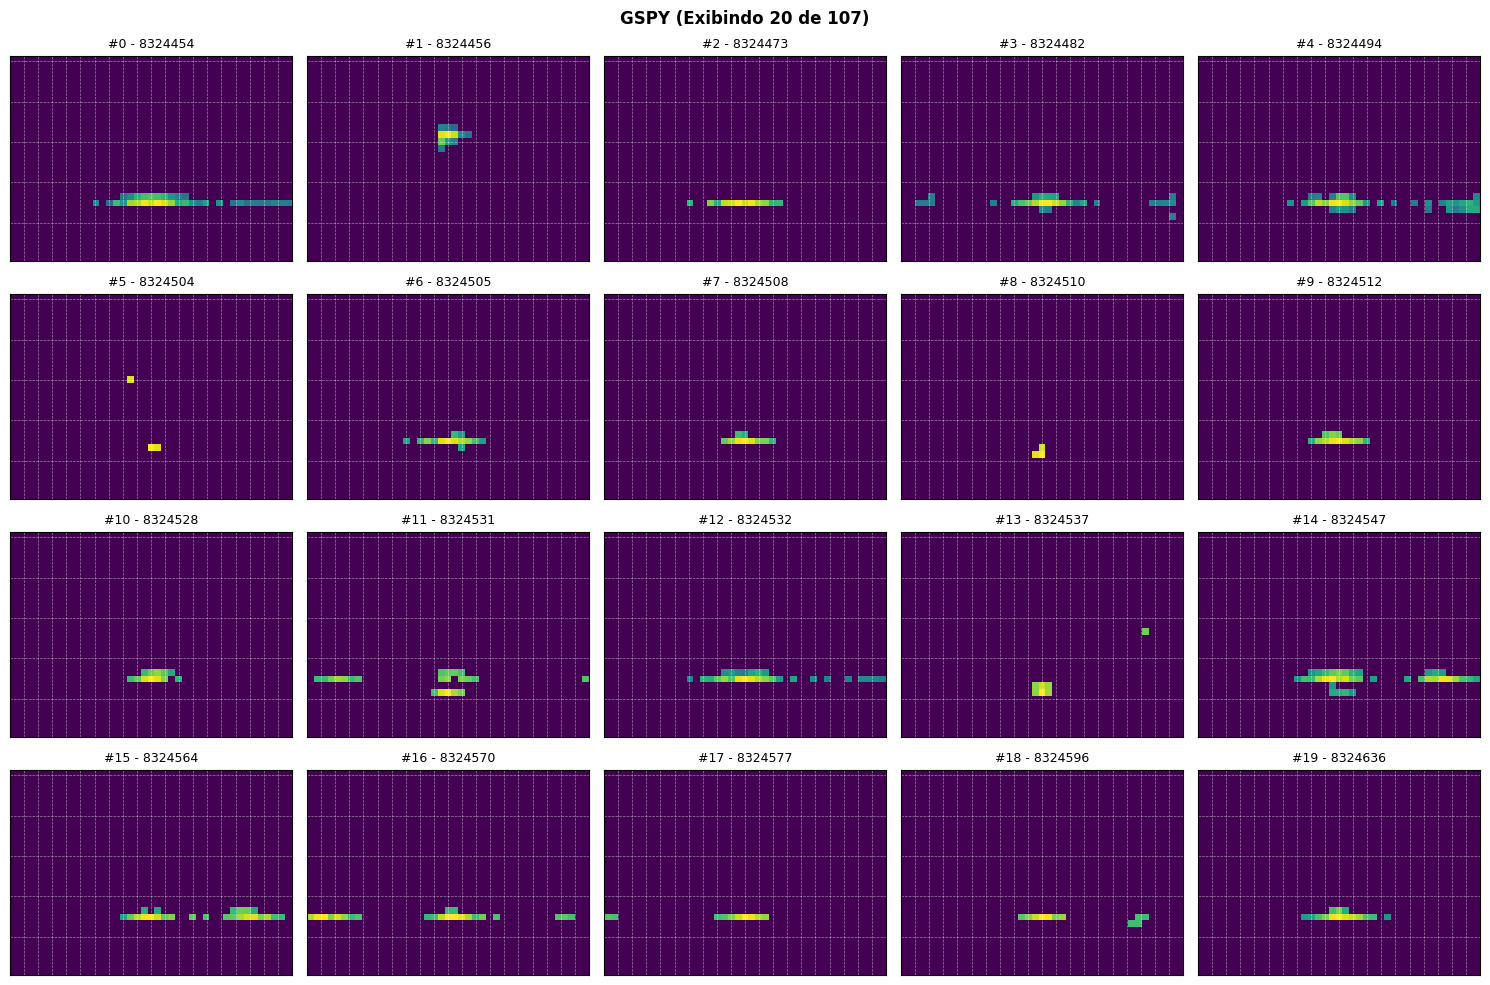

In [478]:
plot_grid2(matrices_gspy, times_gspy, 'GSPY', 20)

GDCHAR

In [479]:
gdchar_data2 = gdchar_data.copy()
gdchar_data2 = gdchar_data2[(gdchar_data2['time'] >= t_inicio_gps) & (gdchar_data2['time'] <= t_fim_gps)]

del gdchar_data
gc.collect();
matrices_gdchar, times_gdchar = create_glitchgram(unclustered, gdchar_data2, deltat)

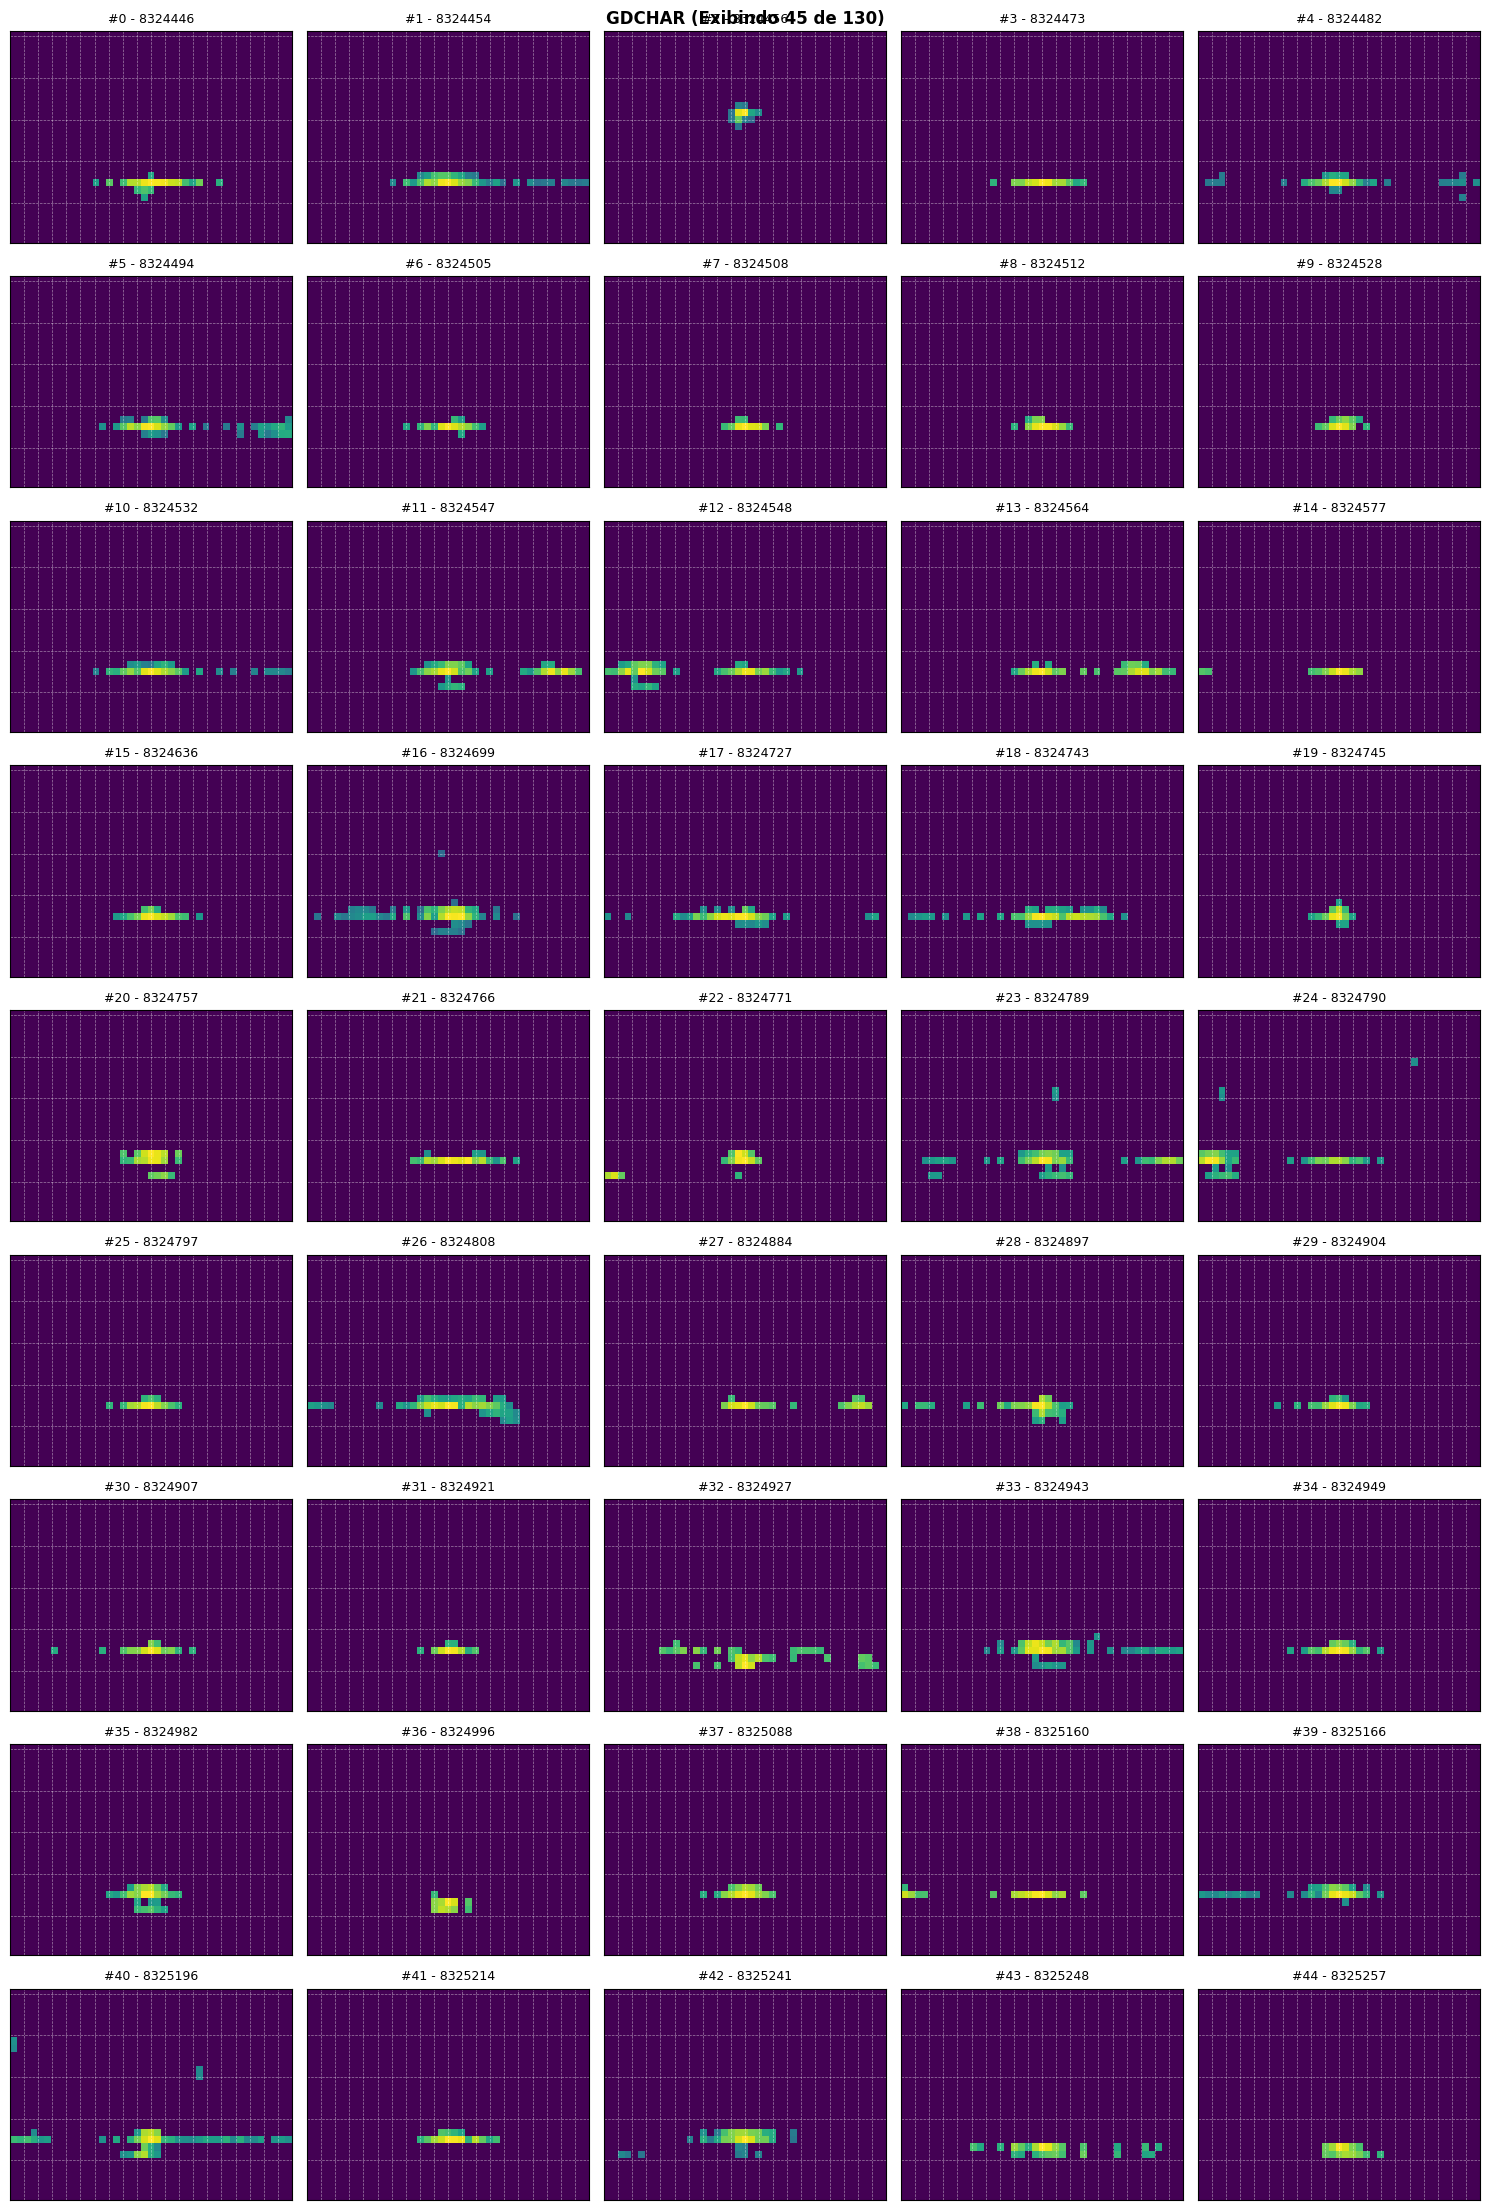

In [480]:
plot_grid2(matrices_gdchar, times_gdchar, 'GDCHAR', 45)

MATCHED

In [481]:
matched2 = matched.copy()
matched2 = matched2[(matched2['time'] >= t_inicio_gps) & (matched2['time'] <= t_fim_gps)]

del matched
gc.collect();
matrices_matched, times_matched = create_glitchgram(unclustered, matched2, deltat)

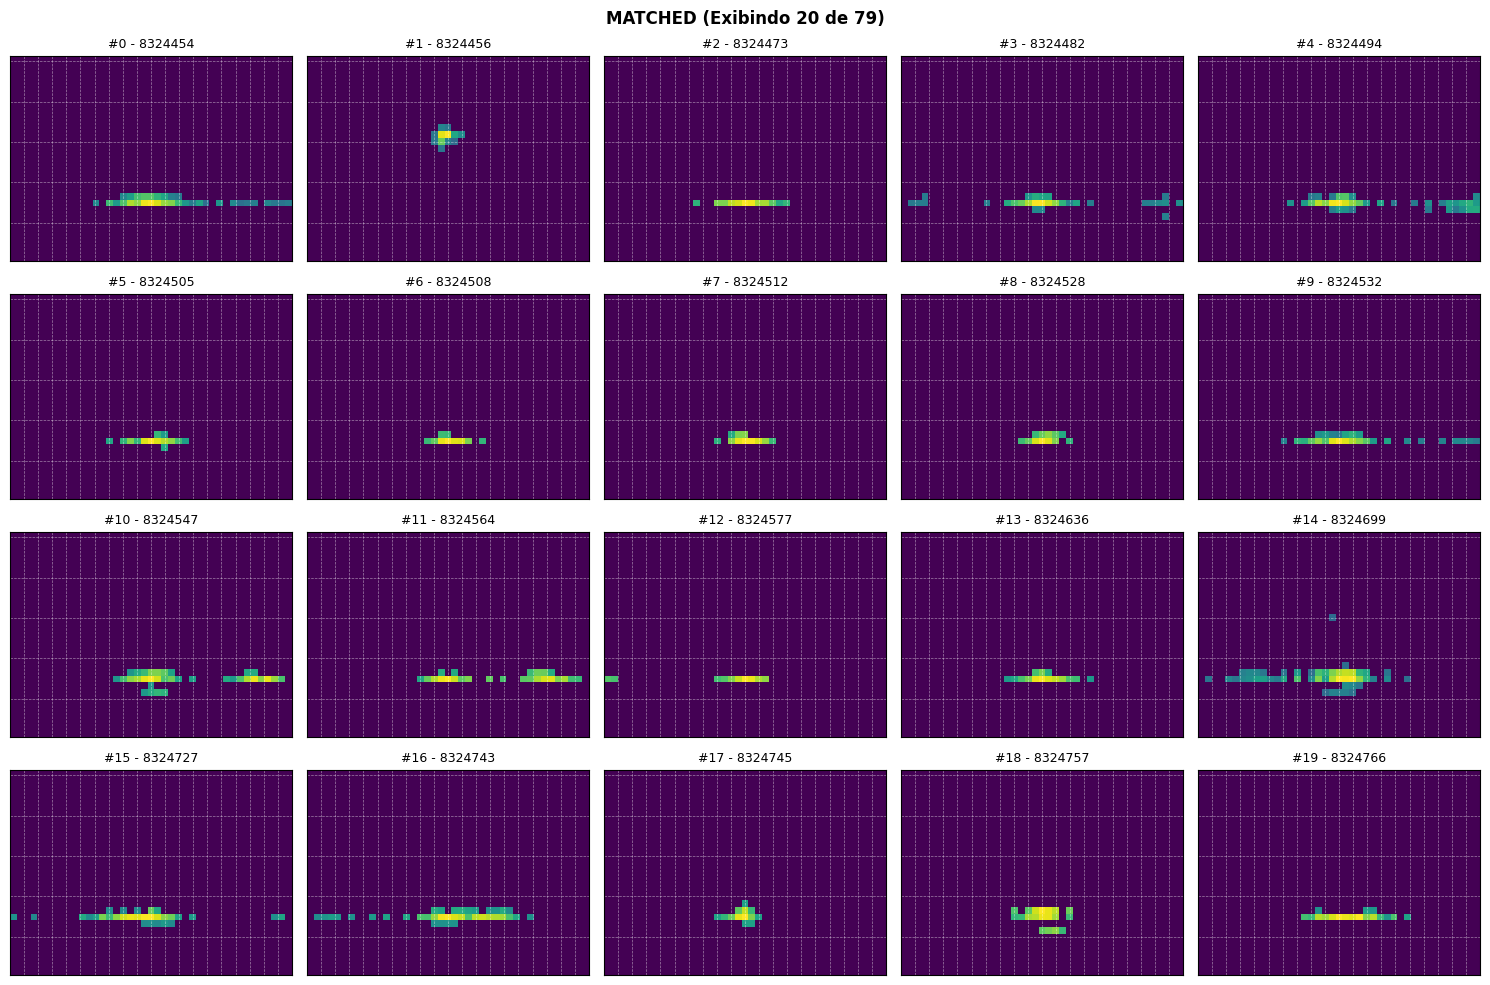

In [482]:
plot_grid2(matrices_matched, times_matched, 'MATCHED', 20)

NON-MATCHED GSPY

In [483]:
non_matched_gspy2 = non_matched_gspy.copy()
non_matched_gspy2 = non_matched_gspy2[(non_matched_gspy2['time'] >= t_inicio_gps) & (non_matched_gspy2['time'] <= t_fim_gps)]

del non_matched_gspy
gc.collect();

matrices_non_matched_gspy, times_non_matched_gspy = create_glitchgram(unclustered, non_matched_gspy2, deltat)

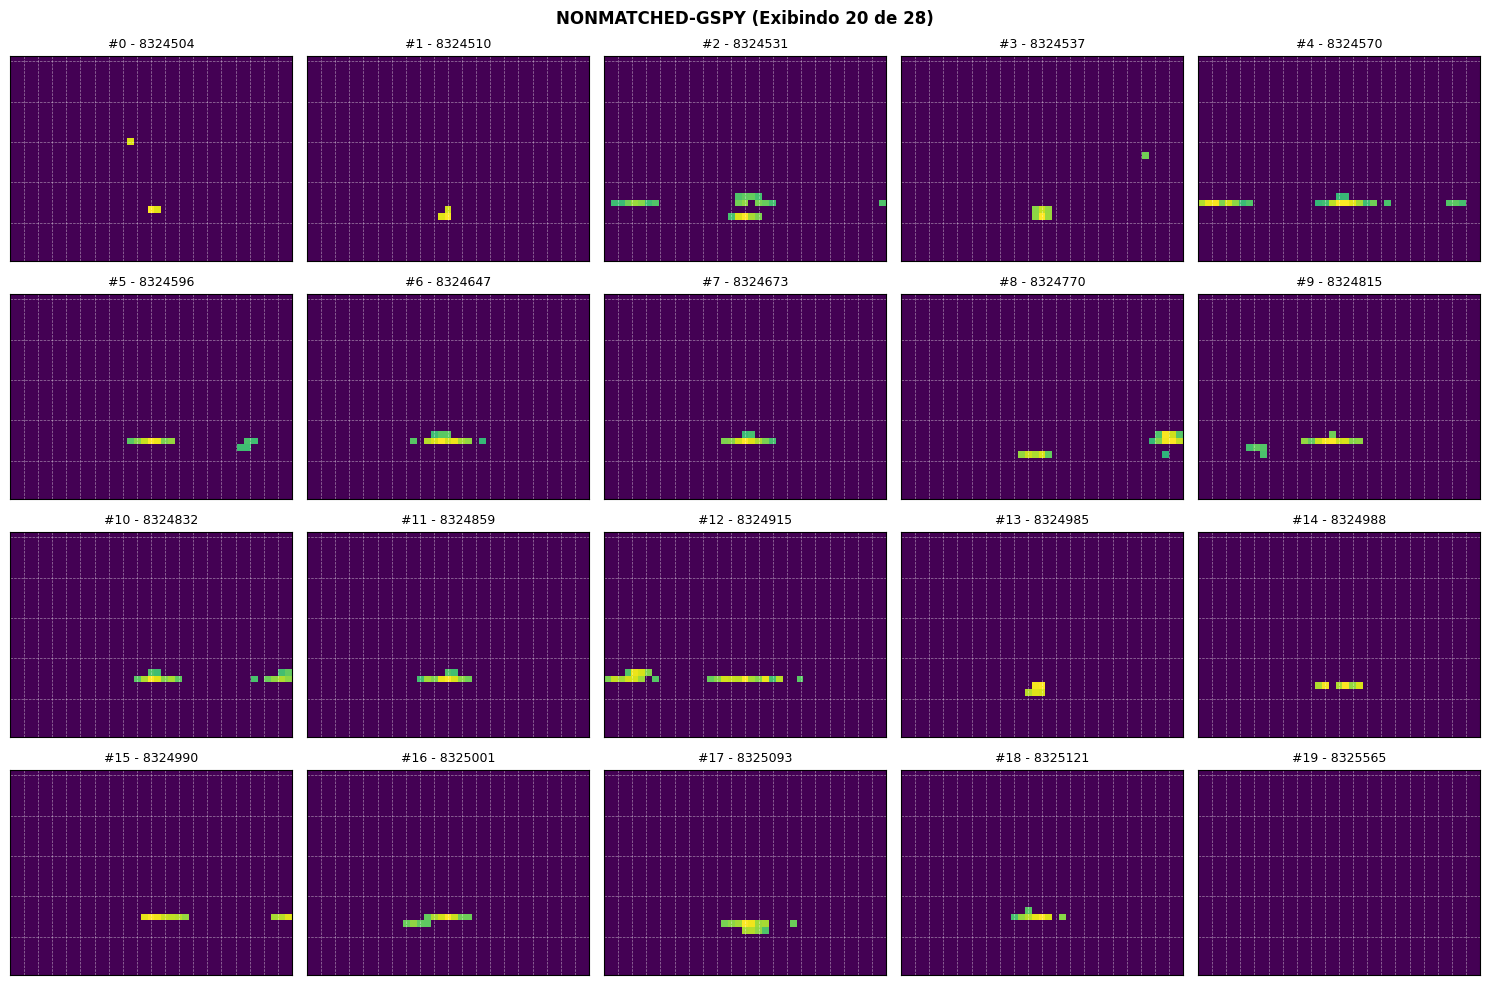

In [484]:
plot_grid2(matrices_non_matched_gspy, times_non_matched_gspy, 'NONMATCHED-GSPY', 20)

NON-MATCHED-GDCHAR

In [485]:
non_matched_gdchar2 = non_matched_gdchar.copy()
non_matched_gdchar2 = non_matched_gdchar2[(non_matched_gdchar2['time'] >= t_inicio_gps) & (non_matched_gdchar2['time'] <= t_fim_gps)]

del non_matched_gdchar
gc.collect();
matrices_non_matched_gdchar, times_non_matched_gdchar = create_glitchgram(unclustered, non_matched_gdchar2, deltat)

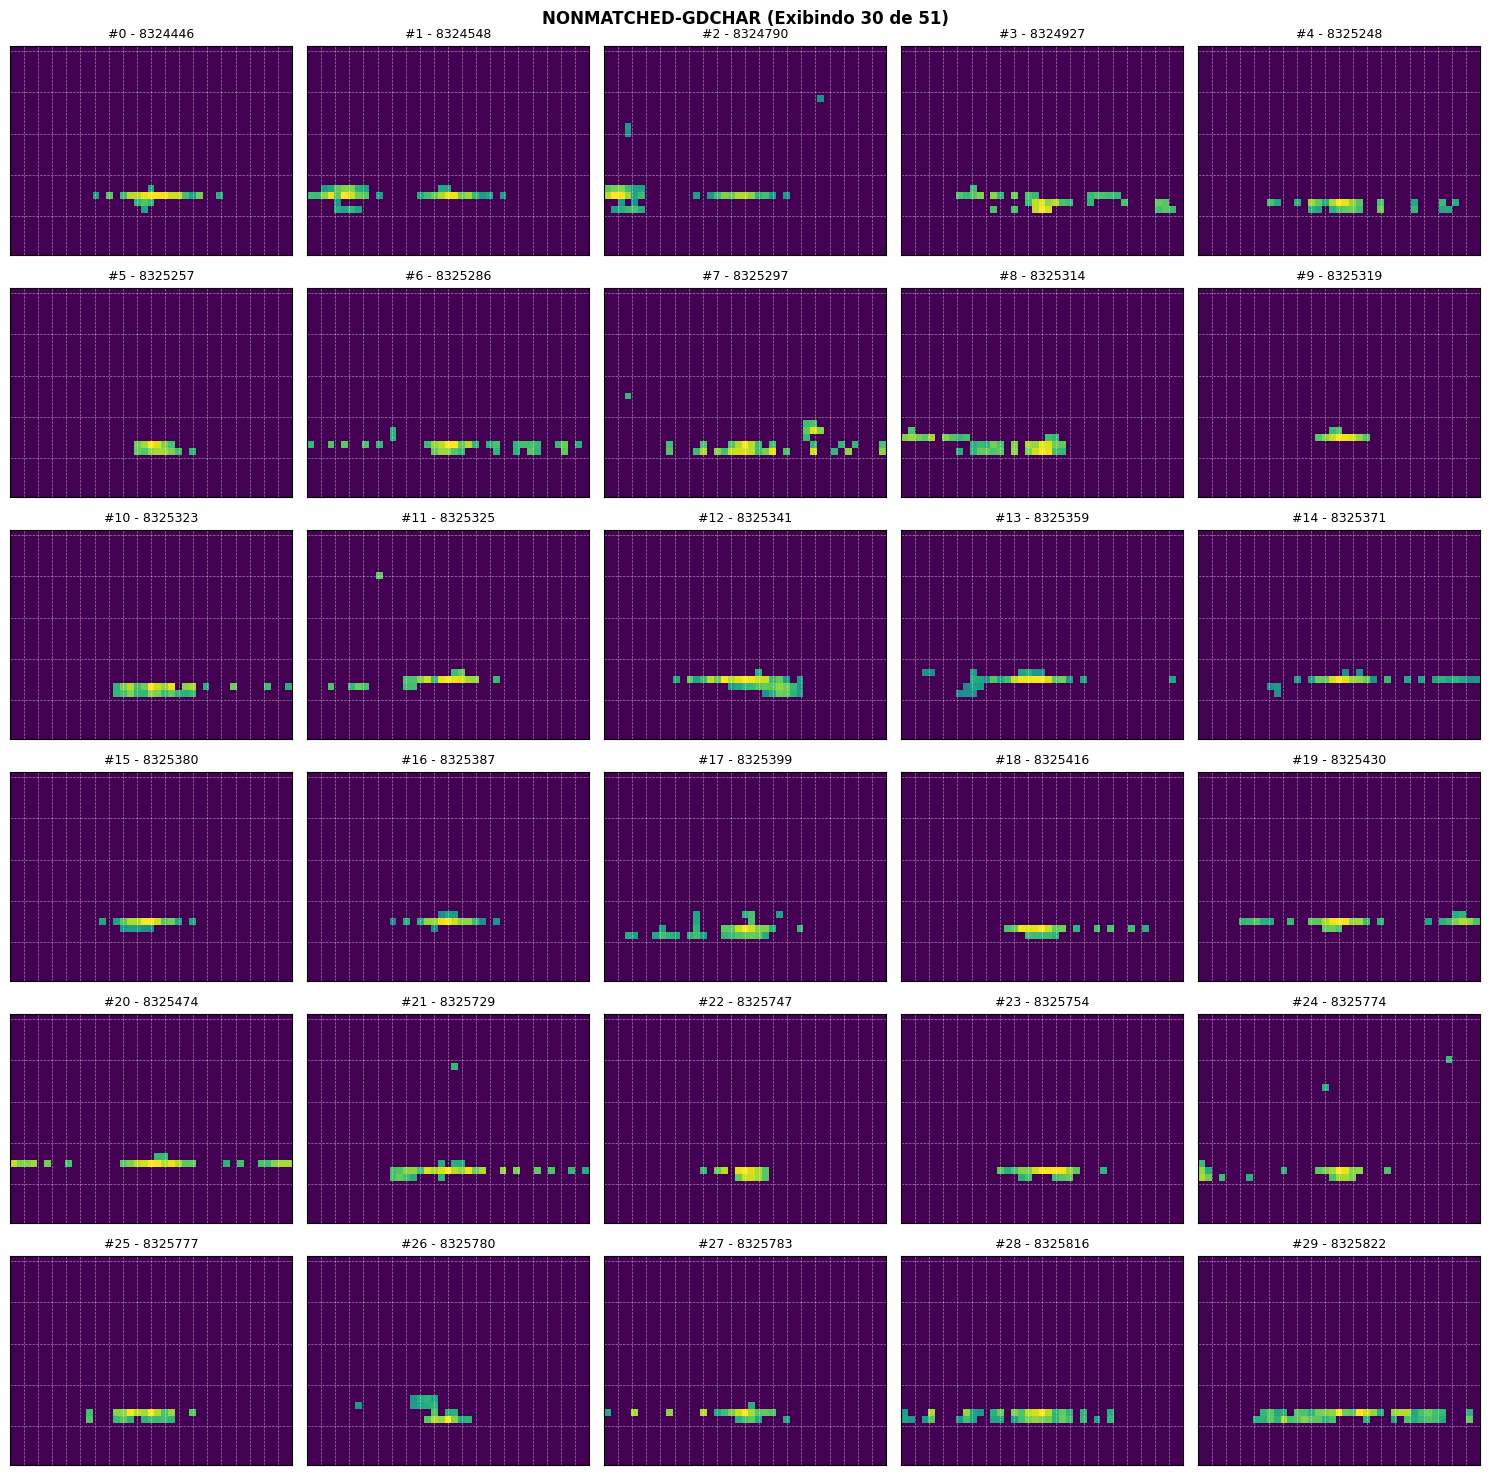

In [486]:
plot_grid2(matrices_non_matched_gdchar, times_non_matched_gdchar, 'NONMATCHED-GDCHAR', 30)

Testes e correções

corte nos bins

In [269]:
import numpy as np

glitchgrams_bincut = []
times_bincut = []

for g, t in zip(matrices_gdchar, times_gdchar):
    
    bins_non_zero = np.count_nonzero(g > 0)
    
    if bins_non_zero > 22: 
        glitchgrams_bincut.append(g)
        times_bincut.append(t)

print(f"Total original: {len(matrices_gdchar)}")
print(f"Total após filtro (> 10 bins não nulos): {len(glitchgrams_bincut)}")
print(f"Total de tempos alinhados: {len(times_bincut)}")

Total original: 45
Total após filtro (> 10 bins não nulos): 19
Total de tempos alinhados: 19


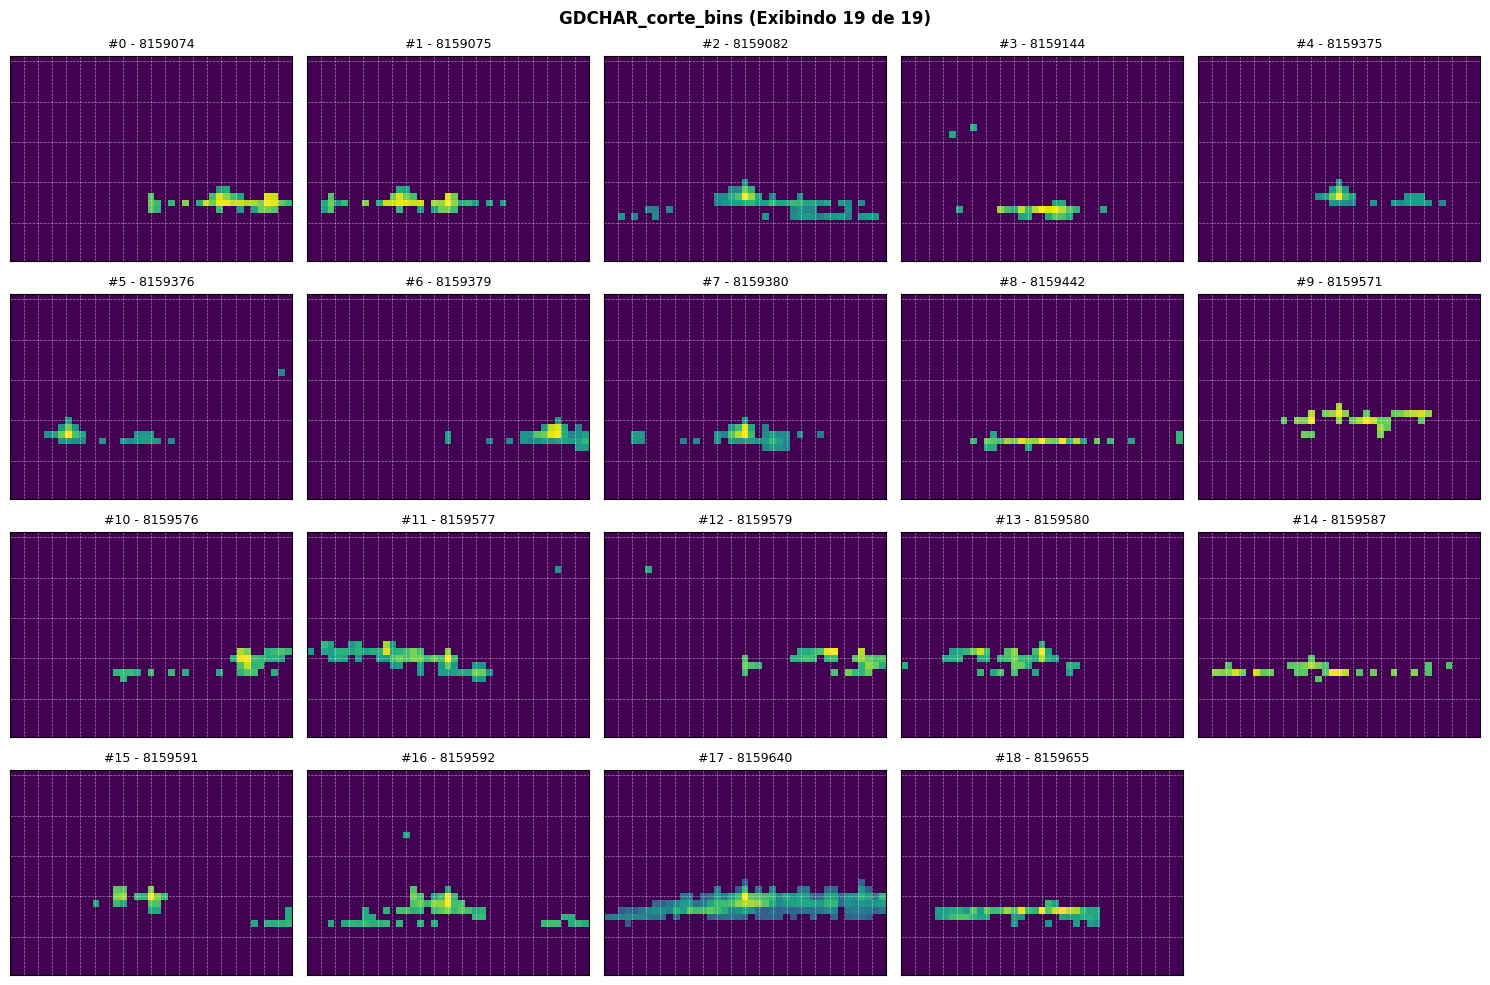

In [270]:
plot_grid2(glitchgrams_bincut, times_bincut, 'GDCHAR_corte_bins', 25)

In [94]:
bruto_gspy = unclustered[(unclustered['time'] >= 1248167640) & (unclustered['time'] <= 1248167646)]

bruto_gspy

,time,frequency,snr
86859739,1248167641.681,1496.999,5.029
86859740,1248167641.682,1475.483,5.467
86859741,1248167641.683,1496.999,5.127
86859742,1248167641.685,1496.999,5.064
86859743,1248167641.686,1475.483,5.223
86859744,1248167643.062,20.390,5.359
86859745,1248167643.125,20.025,5.556
86859746,1248167643.125,20.317,5.590
86859747,1248167643.141,18.820,5.653
86859748,1248167643.141,23.367,5.502


In [99]:
gspy_data2.iloc[2]['time']

np.float64(1248167643.219)

In [108]:
snr = gspy_data2.iloc[2]['snr']

In [109]:
snr

np.float64(7.507)

In [106]:
t_gspy_completo = gspy_data2.iloc[2]['time']
print("Tempo GPS completo do Gravity Spy:", t_gspy_completo)

# 2. Busca na tabela unclustered com o tempo GPS real (+/- 5 segundos)
bruto_real = unclustered[(unclustered['time'] >= t_gspy_completo - 10) & (unclustered['time'] <= t_gspy_completo + 10)]

print(f"Triggers encontrados ao redor de {t_gspy_completo}: {len(bruto_real)}")
if len(bruto_real) > 0:
    print(bruto_real)    

Tempo GPS completo do Gravity Spy: 1248167643.219
Triggers encontrados ao redor de 1248167643.219: 45
                   time  frequency   snr
86859739 1248167641.681   1496.999 5.029
86859740 1248167641.682   1475.483 5.467
86859741 1248167641.683   1496.999 5.127
86859742 1248167641.685   1496.999 5.064
86859743 1248167641.686   1475.483 5.223
86859744 1248167643.062     20.390 5.359
86859745 1248167643.125     20.025 5.556
86859746 1248167643.125     20.317 5.590
86859747 1248167643.141     18.820 5.653
86859748 1248167643.141     23.367 5.502
86859749 1248167643.141     20.970 6.124
86859750 1248167643.148     21.776 5.566
86859751 1248167643.156     21.824 5.088
86859752 1248167643.156     19.495 6.197
86859753 1248167643.156     18.425 5.279
86859754 1248167643.156     20.627 6.173
86859755 1248167643.164     17.731 5.572
86859756 1248167643.164     21.776 5.582
86859757 1248167643.172     18.820 6.381
86859758 1248167643.172     20.970 6.212
86859759 1248167643.180     17.731 5.

In [58]:
import gc

In [88]:
path = '/home/esanches/Projetos/tSNE/Virgo/zrepository/teste2/O3a/daily_teste1'

In [89]:
t_gspy_completo = 1248167643.219

t_inicio = t_gspy_completo - 2
t_fim = t_gspy_completo + 2

t_inicio = Time(t_inicio, format='gps').utc.datetime
t_fim = Time(t_fim, format='gps').utc.datetime

# Roda a tua rotina de clusterização focada apenas nessa janela temporal curta
df_teste_cluster = routine(t_inicio, t_fim, unclustered, path)

print(f"Clusters encontrados no teste: {len(df_teste_cluster)}")
if len(df_teste_cluster) > 0:
    print(df_teste_cluster[['time', 'snr', 'num_triggers']])

Processing day: 2019-07-26
Triggers count for this day: 247620


Glitches count for this day: 593

Successfully saved: /home/esanches/Projetos/tSNE/Virgo/zrepository/teste2/O3a/daily_teste1/glitches_2019-07-26.parquet

Processing complete. Next available global_cluster_ID: 593
Clusters encontrados no teste: 593
              time   snr  num_triggers
0   1248134576.125 6.928            20
1   1248134606.812 7.150            22
2   1248135490.072 6.524            55
3   1248135791.283 6.498            22
4   1248137188.969 6.312            29
..             ...   ...           ...
588 1248218328.281 6.810            25
589 1248219738.777 7.106            28
590 1248219917.582 6.121            22
591 1248220127.016 6.035            30
592 1248220797.031 7.523            40

[593 rows x 3 columns]


In [90]:
# Procura o cluster gerado pelo teu pipeline na janela de +/- 5 segundos do evento do GSPY
t_gspy_completo = 1248167643.219
cluster_encontrado = df_teste_cluster[
    (df_teste_cluster['time'] >= t_gspy_completo - 5) & 
    (df_teste_cluster['time'] <= t_gspy_completo + 5)
]

print("Cluster gerado pelo teu pipeline para este evento:")
print(cluster_encontrado[['time', 'snr', 'num_triggers']])

Cluster gerado pelo teu pipeline para este evento:
              time   snr  num_triggers
379 1248167643.219 6.907            37


In [46]:


matrices_gspy, times_gspy = create_glitchgram(unclustered, gspy_data, deltat)

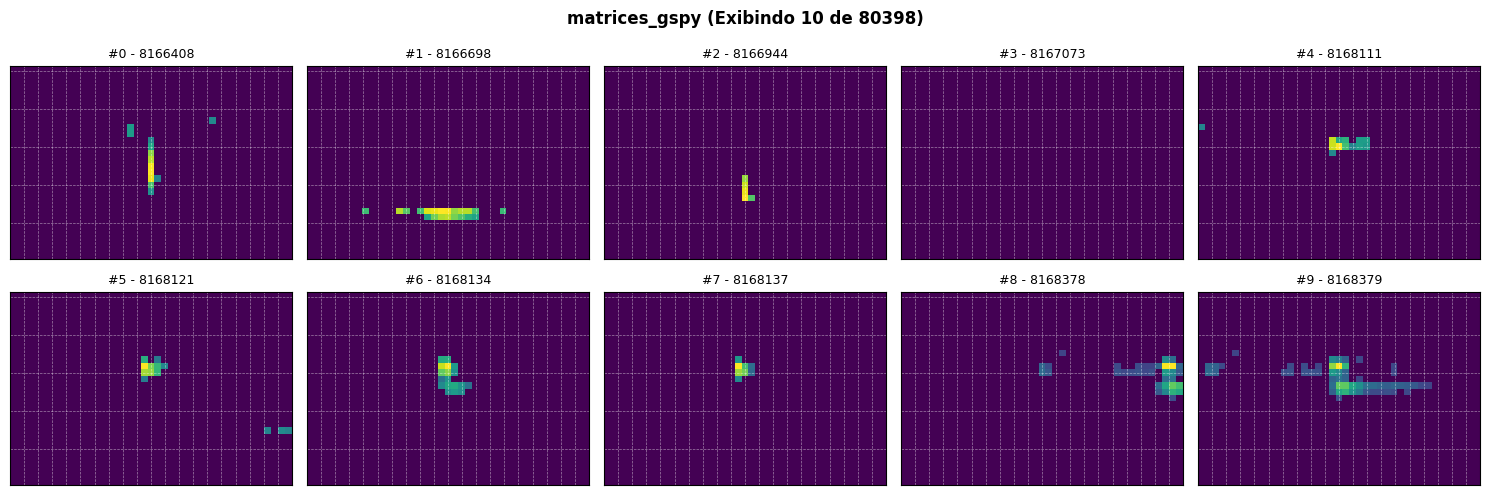

In [48]:
plot_grid2(matrices_gspy, times_gspy, 'matrices_gspy', 10)

In [50]:
matrices_gdchar, times_gdchar = create_glitchgram(unclustered, gdchar_data, deltat)

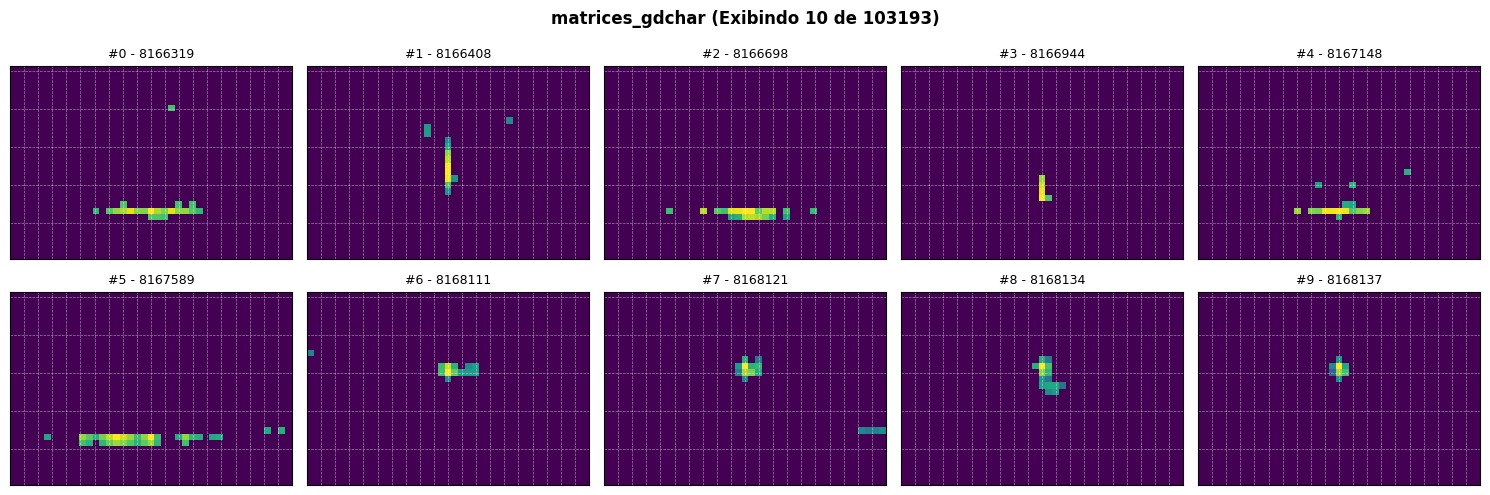

In [51]:
plot_grid2(matrices_gdchar, times_gdchar, 'matrices_gdchar', 10)

In [52]:
# start_day_O3a = datetime(2019, 8, 7, 0, 0, 0)
# end_day_O3a   = datetime(2019, 8, 7, 23, 0, 0)

# t_inicio_gps = Time(start_day_O3a, scale="utc").gps
# t_fim_gps   = Time(end_day_O3a, scale="utc").gps

t_inicio_gps = 1248166408
t_fim_gps = 1248168319

### Calculate matched by tolerance values

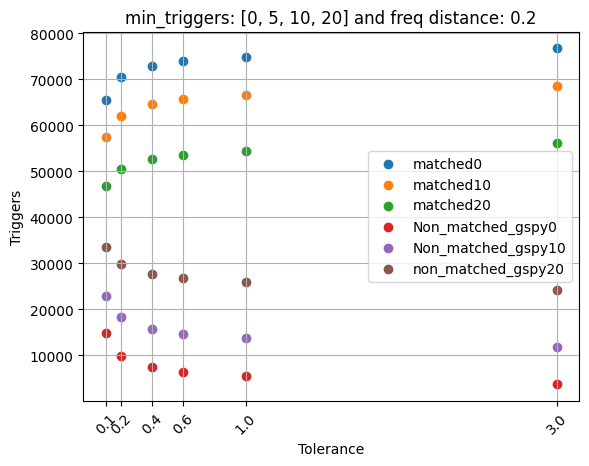

In [17]:
tolerance = [0.1, 0.2, 0.4, 0.6, 1.0, 3.0]

matched0 = [65466, 70546, 72989, 73934, 74917, 76727]
matched5 = [0, 0, 0, 0, 0, 0]
matched10 = [57419, 62110, 64717, 65722, 66601, 68613]
matched20 = [46776, 50615, 52784, 53659, 54500, 56200]

non_matched_gspy0 = [14930, 9850, 7407, 6462, 5479, 3669]
# non_matched_gspy5 = [0, 0, 0, 0, 0, 0]
non_matched_gspy10 = [22977, 18286, 15679, 14674, 13795, 11783]
non_matched_gspy20 = [33620, 29781, 27612, 26737, 25896, 24196]

# non_matched_gdchar = [3690792, 3685712, 3683269, 3682324, 3681341, 3679531]

plt.scatter(tolerance, matched0, label = 'matched0')
# plt.scatter(tolerance, matched5, label = 'matched5')
plt.scatter(tolerance, matched10, label = 'matched10')
plt.scatter(tolerance, matched20, label = 'matched20')

plt.scatter(tolerance, non_matched_gspy0, label = 'Non_matched_gspy0')
# plt.scatter(tolerance, non_matched_gspy5, label = 'non_matched_gspy5')
plt.scatter(tolerance, non_matched_gspy10, label = 'Non_matched_gspy10')
plt.scatter(tolerance, non_matched_gspy20, label = 'non_matched_gspy20')

plt.title(f'min_triggers: [0, 5, 10, 20] and freq distance: 0.2')
plt.ylabel('Triggers')
plt.xlabel('Tolerance')
# plt.yscale('log')

plt.xticks(tolerance, rotation=45)
plt.legend()
plt.grid()
plt.show()

## Generate MATCHEDs Glitchgrams

In [17]:
cluster = matched.copy()

clustered_gdchar = cluster[['time', 'frequency', 'snr_x']]
clustered_gspy = cluster[['GPStime', 'peakFreq', 'snr_y']].rename(columns={'GPStime': 'time'})

In [18]:
matrices_match_gdchar, times_gdchar = create_glitchgram(unclustered, clustered_gdchar, deltat)
matrices_match_gspy, times_gspy = create_glitchgram(unclustered, clustered_gspy, deltat)

arr_gdchar = np.array(matrices_match_gdchar)
arr_gspy = np.array(matrices_match_gspy)

Glitchgrams comparison

In [19]:
seed = 17
np.random.seed(seed)

num_total = len(arr_gdchar)
indices_sorteados = np.random.choice(num_total, size=10, replace=False)

indices_sorteados

array([ 5813, 16275, 10386, 11969, 36104, 12824, 48385, 35375, 13705,
       35313])

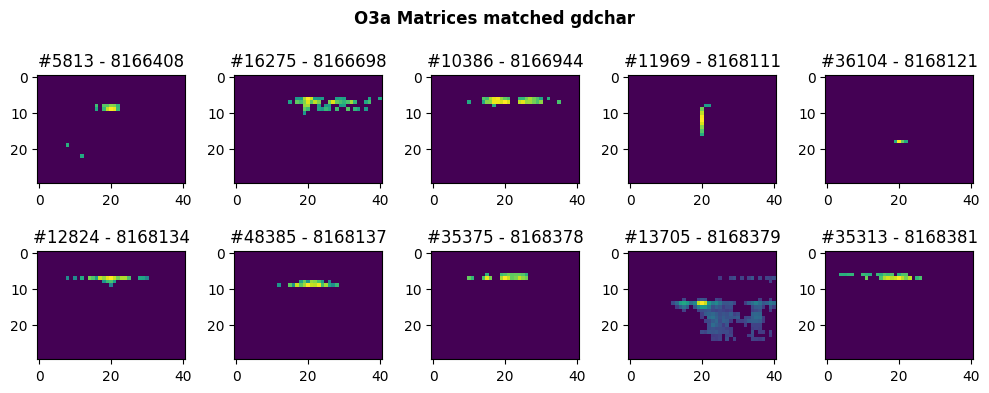

In [32]:
plot_comparison(indices_sorteados, arr_gdchar, times_gdchar, 'matched gdchar', run)

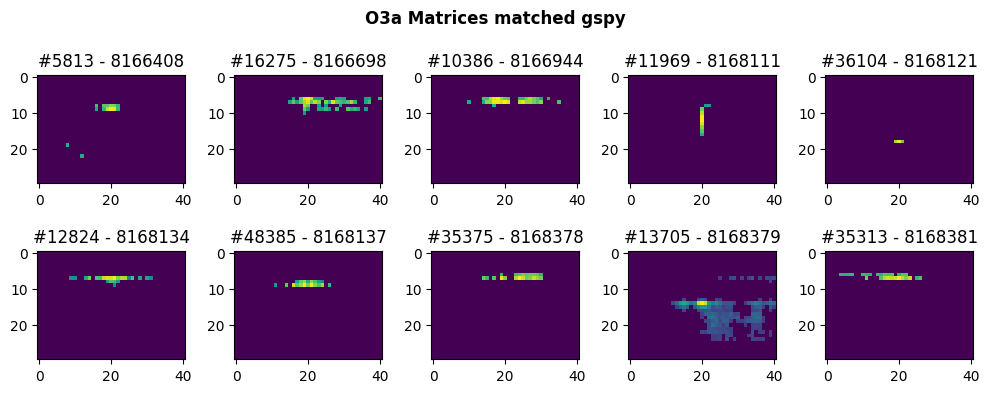

In [104]:
plot_comparison(indices_sorteados, arr_gspy, times_gspy, 'matched gspy', run)

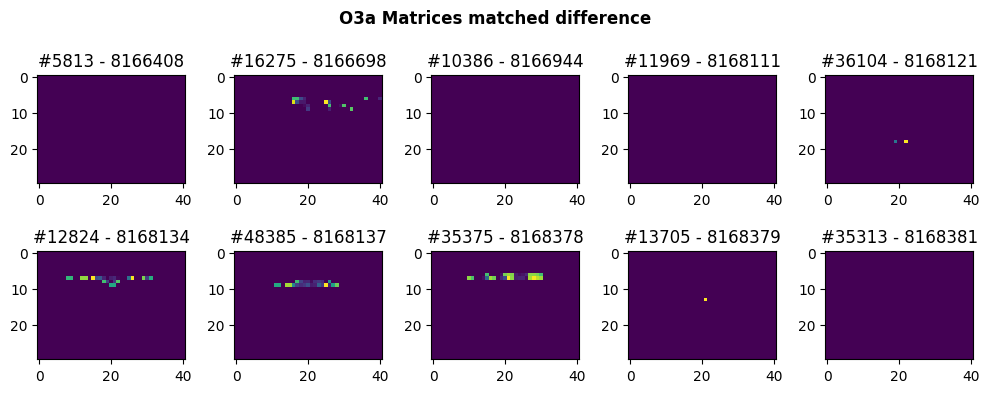

In [105]:
matrice_diff = abs(arr_gdchar - arr_gspy)
plot_comparison(indices_sorteados, matrice_diff, times_gdchar, 'matched difference', run)

By examining the glitchgrams from our clustering process and Gravity Spy, we concluded that our match is correct. 

The difference glitchgrams confirm that the data are not identical but merely exhibit a slight temporal offset relative to each other.

## Generate NON_MATCHED glitchgrams

In [21]:
non_matched_gspy

,GPStime,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value
0,1.248884e+09,377.468,8.015,1.320000e-22,374.989,0.625,26.690920,0.0,0.0,0.592,XyAP7TvA6Z,V1,Whistle,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
1,1.248884e+09,164.337,9.393,1.550000e-22,3375.573,0.313,6448.560547,0.0,0.0,0.218,BI3baQ29b4,V1,Whistle,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
2,1.248884e+09,162.791,10.331,1.650000e-22,4041.092,0.915,7818.782227,0.0,0.0,0.532,UdtWpydP6T,V1,No_Glitch,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627
3,1.248884e+09,377.468,9.630,1.410000e-22,490.771,0.547,258.298553,0.0,0.0,0.681,pRc0BIz0ig,V1,Violin_Mode,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
4,1.248884e+09,162.791,8.984,1.370000e-22,163.458,0.703,24.330690,0.0,0.0,0.430,FMkgGhdMNB,V1,Scratchy,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30272,1.253975e+09,19.896,7.619,1.410000e-21,3909.822,1.500,7783.627441,0.0,0.0,0.991,8WQeFNzWf4,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
30273,1.253975e+09,33.461,12.332,4.140000e-22,3983.241,0.188,7934.482910,0.0,0.0,0.764,489LqPlTZB,V1,None_of_the_Above,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,5.657
30274,1.253977e+09,1198.087,113.390,4.530000e-21,3983.241,1.250,7934.482910,0.0,0.0,0.875,OAdOeIZ59l,V1,Koi_Fish,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,11.314
30275,1.253977e+09,20.168,9.750,1.910000e-21,3983.241,4.748,7934.482910,0.0,0.0,0.951,elTP3iCl5U,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627


In [22]:
cluster1 = non_matched_gdchar.copy()
cluster2 = non_matched_gspy.copy()

clustered_gdchar = cluster1[['time', 'frequency', 'snr']]
clustered_gspy = cluster2[['GPStime', 'peakFreq', 'snr']].rename(columns={'GPStime': 'time'})

In [23]:
clustered_gspy

,time,peakFreq,snr
0,1.248884e+09,377.468,8.015
1,1.248884e+09,164.337,9.393
2,1.248884e+09,162.791,10.331
3,1.248884e+09,377.468,9.630
4,1.248884e+09,162.791,8.984
...,...,...,...
30272,1.253975e+09,19.896,7.619
30273,1.253975e+09,33.461,12.332
30274,1.253977e+09,1198.087,113.390
30275,1.253977e+09,20.168,9.750


In [24]:
clustered_gdchar

,time,frequency,snr
0,1.238166e+09,24.171913,7.513311
1,1.238167e+09,21.824261,8.541214
2,1.238168e+09,19.173992,8.380983
3,1.238170e+09,18.359055,8.498590
4,1.238170e+09,19.173992,8.204130
...,...,...,...
61920,1.253973e+09,45.457336,8.208326
61921,1.253973e+09,25.851009,7.576200
61922,1.253974e+09,20.970167,7.670304
61923,1.253974e+09,29.544662,11.243507


In [25]:
'''t_inicio_gps = int(Time('2019-07-10T10:00:00', format='isot', scale='utc').gps) # 1246626018
t_fim_gps    = int(Time('2019-07-11T23:00:00', format='isot', scale='utc').gps) # 1246633218'''

start_day_O3a = datetime(2019, 8, 7, 0, 0, 0)
end_day_O3a   = datetime(2019, 8, 7, 23, 0, 0)

t_inicio_gps = Time(start_day_O3a, scale="utc").gps
t_fim_gps   = Time(end_day_O3a, scale="utc").gps

In [26]:
clustered_gdchar = clustered_gdchar.sort_values(by="time").reset_index(drop=True)
mask_gdchar = (clustered_gdchar['time'] >= t_inicio_gps) & (clustered_gdchar['time'] <= t_fim_gps)

matrices_nomatch_gdchar, times_non_gdchar = create_glitchgram(unclustered, clustered_gdchar, deltat)

arr_gdchar1 = np.array(matrices_nomatch_gdchar)[mask_gdchar]
times_gdchar1 = np.array(times_non_gdchar)[mask_gdchar]

idx_gdchar = np.argsort(times_gdchar1)

arr_gdchar1 = arr_gdchar1[idx_gdchar]
times_gdchar1 = times_gdchar1[idx_gdchar]



In [33]:
plot_grid(arr_gdchar1, times_gdchar1, "Non-Matched GDCHAR")

In [28]:
clustered_gspy = clustered_gspy.sort_values(by="time").reset_index(drop=True)
mask_gspy = (clustered_gspy['time'] >= t_inicio_gps) & (clustered_gspy['time'] <= t_fim_gps)
matrices_nomatch_gspy, times_non_gspy = create_glitchgram(unclustered, clustered_gspy, deltat)

arr_gspy2 = np.array(matrices_nomatch_gspy)[mask_gspy]
times_gspy2 = np.array(times_non_gspy)[mask_gspy]

idx_gspy = np.argsort(times_gspy2)
arr_gspy2 = arr_gspy2[idx_gspy]
times_gspy2 = times_gspy2[idx_gspy]



In [34]:
plot_grid(arr_gspy2, times_gspy2, "Non-Matched GSPY")

/////////////////////////////////////////////////////////////

In [40]:
# TESTE 1: Esse glitch existe na tabela de entrada bruta (gltab)?
bruto = unclustered[(unclustered['time'] >= 9182655) & (unclustered['time'] <= 9182667)]
print("1. Triggers na gltab bruta:", len(bruto))

# TESTE 2: Esse glitch gerou algum cluster no Passo 2 (antes da filtragem min_triggers)?
if len(bruto) > 0:
    print(bruto[['time', 'frequency', 'snr']])

1. Triggers na gltab bruta: 0


In [43]:
gspy_data = pd.read_csv(base + '/gspy' + run + '.csv')
gspy_data.tail()

,GPStime,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value
80393,1.253167e+09,21.276,7.905,1.460000e-21,3680.246,2.013,7328.491699,0.0,0.0,0.187,axFS82a5rf,V1,Light_Modulation,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627
80394,1.253478e+09,19.950,7.959,1.800000e-21,42.988,0.500,53.975620,0.0,0.0,0.184,aH3vyF6Rc1,V1,None_of_the_Above,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627
80395,1.244633e+09,418.816,8.968,2.010000e-22,302.104,0.359,547.768860,0.0,0.0,0.177,fgQ0bycRBj,V1,None_of_the_Above,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627
80396,1.240533e+09,116.576,10.334,1.270000e-22,109.385,0.375,182.753067,0.0,0.0,0.172,vmTmg3Y2x0,V1,Scratchy,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,11.314
80397,1.241687e+09,349.985,8.376,1.570000e-22,324.817,0.703,600.853760,0.0,0.0,0.161,0o9ovV7MEB,V1,Koi_Fish,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627


In [46]:
# 1. Garante que os dados estão ordenados por tempo
df_gspy_sorted = gspy_data.rename(columns={'GPStime': 'time'})
df_gspy_sorted = df_gspy_sorted.sort_values(by="time").reset_index(drop=True)

# 2. Gera as matrizes e os tempos GPS correspondentes
matrices_gspy, times_gspy = create_glitchgram(unclustered, df_gspy_sorted, deltat)

# 3. Converte para arrays numpy para facilitar o plot
arr_gspy = np.array(matrices_gspy)
times_gspy = np.array(times_gspy)

In [1]:
# Filtra o DataFrame do Gravity Spy para o intervalo desejado
mask = (df_gspy_sorted['time'] >= 9182600) & (df_gspy_sorted['time'] <= 9183000)
df_gspy_sub = df_gspy_sorted[mask].reset_index(drop=True)

# Gera e plota apenas essa seleção
matrices_sub, times_sub = create_glitchgram(unclustered, df_gspy_sub, deltat)

plot_grid(
    arr=np.array(matrices_sub), 
    times=np.array(times_sub), 
    title="Gravity Spy (Intervalo Selecionado)",
    t_min=-1.0, 
    t_max=1.0
)

NameError: name 'df_gspy_sorted' is not defined

In [ ]:
plot_grid(
    arr=arr_gspy, 
    times=times_gspy, 
    title="Glitches - Gravity Spy",
    t_min=-1.0, 
    t_max=1.0
)

### Encontrar para cada tempo em gdchar se existe algum próximo em gspy

In [35]:
# Tolerância em segundos (ex: 10 milissegundos)
dt = 1

# Encontra para cada tempo em gdchar se existe algum próximo em gspy
# (Como os arrays já estão ordenados por tempo no seu código, searchsorted é extremamente rápido)
idx_gspy_nearest = np.searchsorted(times_gspy2, times_gdchar1)
idx_gspy_nearest = np.clip(idx_gspy_nearest, 0, len(times_gspy2) - 1)

# Calcula a diferença absoluta de tempo
time_diff = np.abs(times_gdchar1 - times_gspy2[idx_gspy_nearest])

# Máscara de interseções dentro da tolerância dt
mask_intersect = time_diff <= dt

# Tempos e matrizes que deram match dentro da janela dt:
common_times_gdchar = times_gdchar1[mask_intersect]
common_arr_gdchar   = arr_gdchar1[mask_intersect]

common_times_gspy   = times_gspy2[idx_gspy_nearest[mask_intersect]]
common_arr_gspy     = arr_gspy2[idx_gspy_nearest[mask_intersect]]

print(f"Total de glitches próximos em dt < {dt}s: {len(common_times_gdchar)}")

Total de glitches próximos em dt < 1s: 4


In [36]:
common_times_gdchar

array([1.24917283e+09, 1.24917953e+09, 1.24924049e+09, 1.24924243e+09])

In [37]:
common_times_gspy

array([1.24917283e+09, 1.24917953e+09, 1.24924049e+09, 1.24924243e+09])

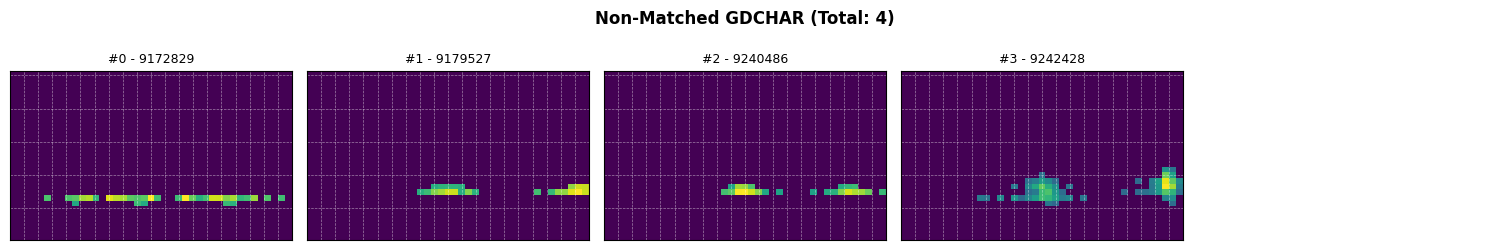

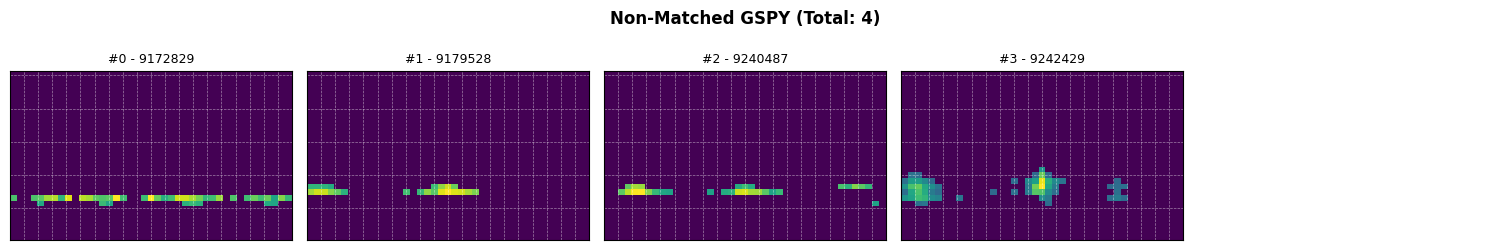

In [38]:
plot_grid(common_arr_gdchar, common_times_gdchar, "Non-Matched GDCHAR")
plot_grid(common_arr_gspy, common_times_gspy, "Non-Matched GSPY")

### Encontrar o glitch mais próximo de um determinado tempo GPS

In [159]:
X = 1248912116.0

In [160]:
idx_nearest_gdchar = np.argmin(np.abs(times_gdchar1 - X))
closest_time_gdchar = times_gdchar1[idx_nearest_gdchar]
diff_gdchar = abs(closest_time_gdchar - X)

print(f'closest_time_gdchar: {closest_time_gdchar} \n')
print(f'diff_gdchar: {diff_gdchar} \n')

closest_time_gdchar: 1248820740.6875 

diff_gdchar: 91375.3125 



In [161]:
idx_nearest_gspy = np.argmin(np.abs(times_gspy2 - X))
closest_time_gspy = times_gdchar1[idx_nearest_gspy]
diff_gspy = abs(closest_time_gspy - X)

print(f'closest_time_gspy: {closest_time_gspy} \n')
print(f'diff_gspy: {diff_gspy} \n')

closest_time_gspy: 1248740829.96875 

diff_gspy: 171286.03125 



In [45]:
# 1. Verifica quantos eventos existem no intervalo no DataFrame original
qtd_df = mask_gspy.sum()
print(f"Glitches de GSPY no intervalo de tempo (no DataFrame): {qtd_df}")

# 2. Verifica se a função retornou a mesma quantidade de matrizes/tempos
print(f"Total de matrizes geradas pelo create_glitchgram: {len(matrices_nomatch_gspy)}")
print(f"Total de tempos gerados pelo create_glitchgram: {len(times_non_gspy)}")

# 3. Solução robusta: Criar a máscara diretamente no array retornado pela função!
times_gspy_arr = np.array(times_non_gspy)
matrices_gspy_arr = np.array(matrices_nomatch_gspy)

# Máscara feita diretamente nos tempos retornados pela função (sem perigo de tamanho desalinhado)
mask_real_gspy = (times_gspy_arr >= t_inicio_gps) & (times_gspy_arr <= t_fim_gps)

arr_gspy2 = matrices_gspy_arr[mask_real_gspy]
times_gspy2 = times_gspy_arr[mask_real_gspy]

# Ordenar
idx_gspy = np.argsort(times_gspy2)
arr_gspy2 = arr_gspy2[idx_gspy]
times_gspy2 = times_gspy2[idx_gspy]

print(f"Glitches finais filtrados para plotar: {len(arr_gspy2)}")

Glitches de GSPY no intervalo de tempo (no DataFrame): 0
Total de matrizes geradas pelo create_glitchgram: 18374
Total de tempos gerados pelo create_glitchgram: 18374
Glitches finais filtrados para plotar: 0


In [46]:
print("Tempo MÍNIMO do GSPY:", clustered_gspy["time"].min())
print("Tempo MÁXIMO do GSPY:", clustered_gspy["time"].max())

print("\nSeu t_inicio_gps:", t_inicio_gps)
print("Seu t_fim_gps   :", t_fim_gps)

Tempo MÍNIMO do GSPY: 1250800400.002
Tempo MÁXIMO do GSPY: 1253976851.266

Seu t_inicio_gps: 1246701618
Seu t_fim_gps   : 1246824018
